In [35]:
import numpy as np
import pandas as pd
from pycirclize import Circos
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
r_pancreas = pd.read_csv("ligands_receptors/pancreas_ht224p1/receiver_mean.csv")
s_pancreas = pd.read_csv("ligands_receptors/pancreas_ht224p1/sender_mean.csv")

r_sein = pd.read_csv("ligands_receptors/sein_ht425b1/receiver_mean.csv")
s_sein = pd.read_csv("ligands_receptors/sein_ht425b1/sender_mean.csv")

# Pancreas

In [5]:
r_pancreas.drop(7, inplace=True)

In [6]:
s_pancreas.drop(7, inplace=True)

In [7]:
s_pancreas.columns

Index(['cell_type', 's-PLG-F2R', 's-PLG-F2RL3', 's-PLG-PARD3', 's-PLG-F2RL1',
       's-PLG-F2RL2', 's-UCN2-CRHR1', 's-UCN2-CRHR2', 's-IL9-IL9R_IL2RG',
       's-FSHB-FSHR',
       ...
       's-INSL3-RXFP1', 's-INSL3-RXFP3', 's-INSL3-RXFP2', 's-INSL3-RXFP4',
       's-APLN-APLNR', 's-IAPP-CALCR', 's-IAPP-CALCRL',
       's-INHBA-ACVR1B_ACVR2B', 's-INHBA-ACVR1B_ACVR2A', 's-total-total'],
      dtype='object', length=1196)

In [8]:
n = len(s_pancreas)

In [9]:
matrix_pancreas = np.zeros((n,n))

for name_sender in s_pancreas.columns[1:] :
    l_sender = list(s_pancreas[name_sender])
    l_receiver = list(r_pancreas['r-' + name_sender[2:]])

    for i in range(n):
        for j in range(n):
            matrix_pancreas[i][j] += min(l_sender[i], l_receiver[j])
            

In [10]:
s_pancreas['cell_type']

0                ADM
1            B-cells
2       Ductal-like1
3       Ductal-like2
4        Endothelial
5        Fibroblasts
6             Islets
8        Macrophages
9               Mast
10    Other_doublets
11            Plasma
12           T-cells
13             Tumor
Name: cell_type, dtype: object

In [11]:
df_pancreas = pd.DataFrame(matrix_pancreas, index = list(s_pancreas['cell_type']), columns = list(s_pancreas['cell_type']))

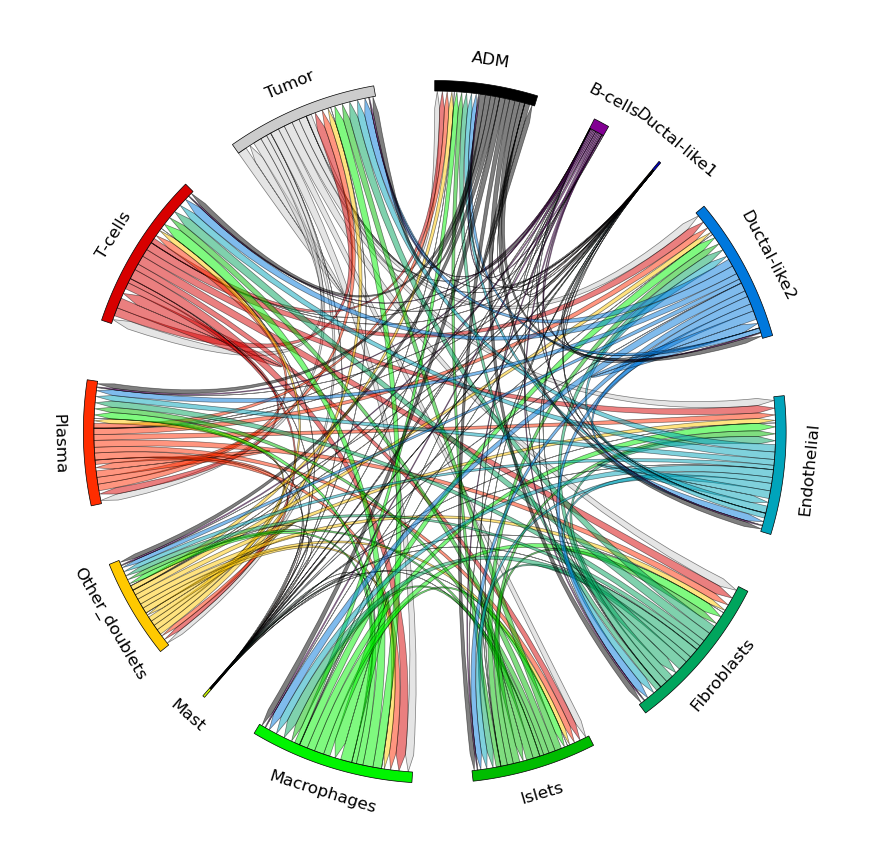

In [12]:
circos = Circos.chord_diagram(
    df_pancreas,
    space=10,
    cmap="nipy_spectral",
    label_kws=dict(size=12),
    link_kws=dict(ec="black", lw=0.5, direction=1),
)

fig = circos.plotfig()

# Sein

In [13]:
r_sein.drop(7, inplace=True)

In [14]:
s_sein.drop(7, inplace=True)

In [15]:
s_sein.columns

Index(['cell_type', 's-IL31-IL31RA_OSMR', 's-IFNK-IFNAR1_IFNAR2',
       's-MIF-ACKR3', 's-MIF-CD74_CXCR4', 's-MIF-CD74_CXCR2',
       's-MIF-CD74_CD44', 's-APELA-APLNR', 's-CCL7-ACKR1', 's-CCL7-CCR1',
       ...
       's-GDF2-ACVRL1_ACVR2A', 's-RARRES2-GPR1', 's-RARRES2-CMKLR1',
       's-FGF17-FGFR3', 's-FGF17-FGFR2', 's-FGF17-FGFR4', 's-FGF17-FGFR1',
       's-BMP10-ACVRL1_BMPR2', 's-BMP10-ACVRL1_ACVR2A', 's-total-total'],
      dtype='object', length=1081)

In [16]:
n = len(s_sein)

In [17]:
matrix_sein = np.zeros((n,n))

for name_sender in s_sein.columns[1:] :
    l_sender = list(s_sein[name_sender])
    l_receiver = list(r_sein['r-' + name_sender[2:]])

    for i in range(n):
        for j in range(n):
            matrix_sein[i][j] += min(l_sender[i], l_receiver[j])
            

In [18]:
s_sein['cell_type']

0       Adipocyte
1               B
2           Basal
3     Endothelial
4      Fibroblast
5           LumHR
6          LumSec
8        Pericyte
9          Plasma
10              T
11          Tumor
12            pDC
Name: cell_type, dtype: object

In [19]:
df_sein = pd.DataFrame(matrix_sein, index = list(s_sein['cell_type']), columns = list(s_sein['cell_type']))
df_sein

,Adipocyte,B,Basal,Endothelial,Fibroblast,LumHR,LumSec,Pericyte,Plasma,T,Tumor,pDC
Adipocyte,2.646079,1.717526,0.507979,3.069049,3.095312,0.306184,2.648578,0.952186,2.741753,2.774191,3.133603,0.656916
B,1.501090,1.537619,0.450557,1.680543,1.740903,0.257545,1.671741,0.845664,1.691336,1.722288,1.766715,0.595760
Basal,0.477225,0.456092,0.361126,0.542210,0.568568,0.199366,0.504923,0.415146,0.516414,0.505721,0.560940,0.327662
Endothelial,2.758533,1.913672,0.553548,6.007560,6.090150,0.344884,5.017308,0.989817,5.092947,5.178473,6.153979,0.752228
Fibroblast,2.785876,1.930595,0.564731,6.629897,9.915844,0.314611,5.663630,0.989576,5.434984,5.553996,10.448817,0.753301
LumHR,0.527253,0.489424,0.362659,0.567894,0.573110,0.227092,0.587513,0.419965,0.578277,0.560534,0.584888,0.352457
LumSec,2.367502,1.819904,0.507782,5.171403,5.554721,0.263933,5.811130,0.932992,5.185519,5.139958,5.806339,0.676472
Pericyte,0.950409,0.927776,0.407340,1.038093,1.059592,0.225869,0.981800,0.787660,1.009369,0.997142,1.067000,0.491843
Plasma,2.491766,1.867565,0.525326,5.409671,5.736465,0.314292,5.403331,0.944483,5.409561,5.308618,5.840773,0.664880
T,2.476782,1.910290,0.523187,4.884172,5.112243,0.301202,4.693787,0.965158,4.893528,5.166399,5.233499,0.662089


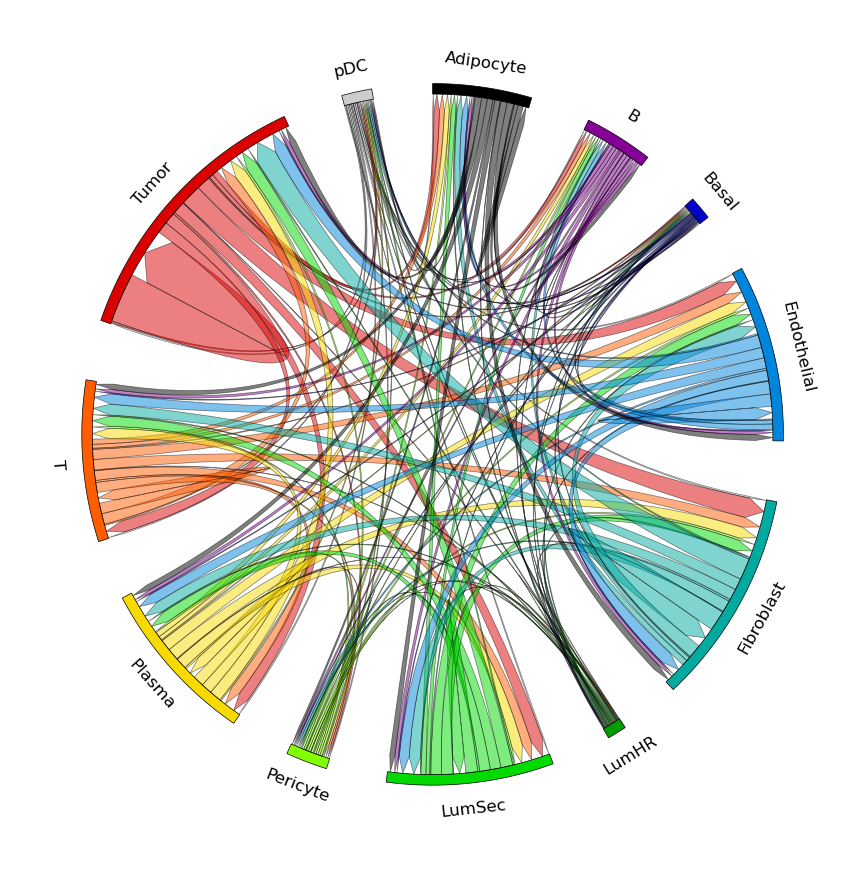

In [20]:
circos = Circos.chord_diagram(
    df_sein,
    space=10,
    cmap="nipy_spectral",
    label_kws=dict(size=12),
    link_kws=dict(ec="black", lw=0.5, direction=1),
)

fig = circos.plotfig()

# Centrality comparaison

In [25]:
def build_ccc_network_from_matrix(mat, threshold=0.0):
    """
    Construit un graphe dirigé pondéré à partir
    d'une matrice source x target
    """
    G = nx.DiGraph()

    for source in mat.index:
        for target in mat.columns:
            weight = mat.loc[source, target]
            if weight > threshold:
                G.add_edge(source, target, weight=weight)

    return G


In [28]:
network_sein = build_ccc_network_from_matrix(df_sein)

In [29]:
network_pancreas = build_ccc_network_from_matrix(df_pancreas)

In [66]:
def compute_centralities(G):
    cent = pd.DataFrame(index=G.nodes())
    cent["out_strength"] = pd.Series(dict(G.out_degree(weight="weight")))
    cent["in_strength"] = pd.Series(dict(G.in_degree(weight="weight")))
    cent["betweenness"] = pd.Series(nx.betweenness_centrality(G, weight="weight", normalized=True))
    cent["eigenvector"] = pd.Series(nx.eigenvector_centrality_numpy(G, weight="weight"))

    return cent.fillna(0)


In [67]:
compute_centralities(network_sein)

,out_strength,in_strength,betweenness,eigenvector
Adipocyte,24.249357,22.433487,0.0,0.154753
B,15.461761,17.082928,0.0,0.112267
Basal,5.435393,5.697687,0.0,0.033140
Endothelial,40.853099,42.540016,0.0,0.332573
Fibroblast,50.985857,50.287798,0.0,0.419590
LumHR,5.831065,3.297091,0.7,0.018779
LumSec,39.237654,39.607101,0.0,0.305504
Pericyte,9.943894,9.750938,0.0,0.058685
Plasma,39.916730,38.747760,0.0,0.294263
T,36.822336,39.287277,0.0,0.299927


In [68]:
def plot_ccc_heatmap(mat, title="", cmap="Reds"):
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        mat,
        cmap=cmap,
        square=True,
        linewidths=0.5
    )
    plt.title(title)
    plt.xlabel("Target cells")
    plt.ylabel("Source cells")
    plt.tight_layout()
    plt.show()

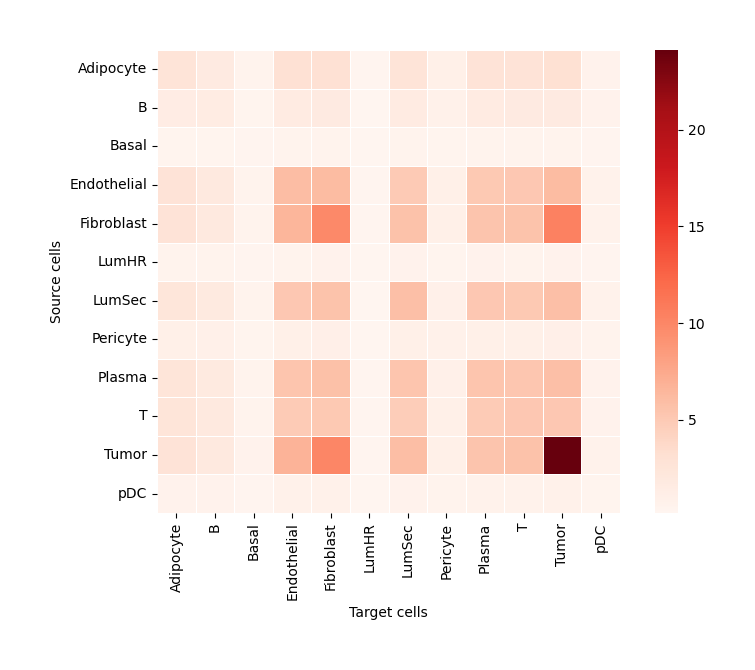

In [69]:
plot_ccc_heatmap(df_sein)

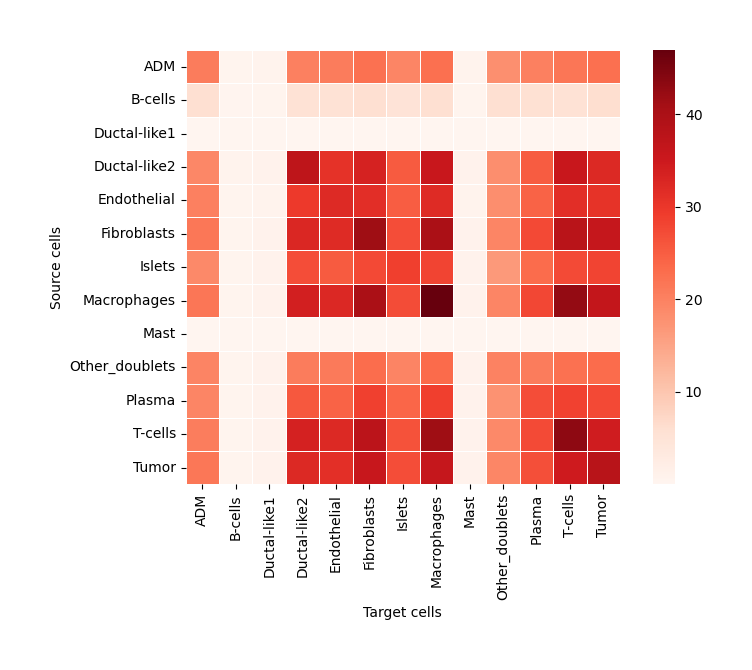

In [70]:
plot_ccc_heatmap(df_pancreas)

In [71]:
def plot_centrality_heatmap(cent, title="Centrality heatmap"):
    cent_norm = (cent - cent.mean()) / cent.std()

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cent_norm,
        cmap="coolwarm",
        center=0,
        linewidths=0.5
    )
    plt.title(title)
    plt.ylabel("Cell types")
    plt.tight_layout()
    plt.show()

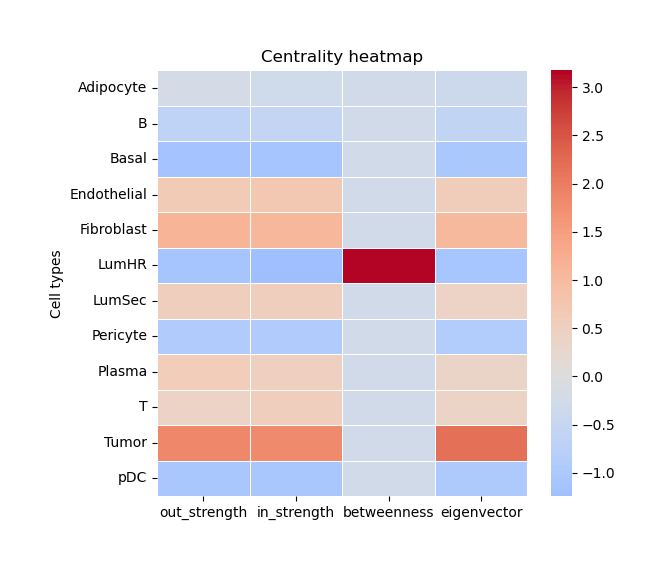

In [72]:
plot_centrality_heatmap(compute_centralities(network_sein))

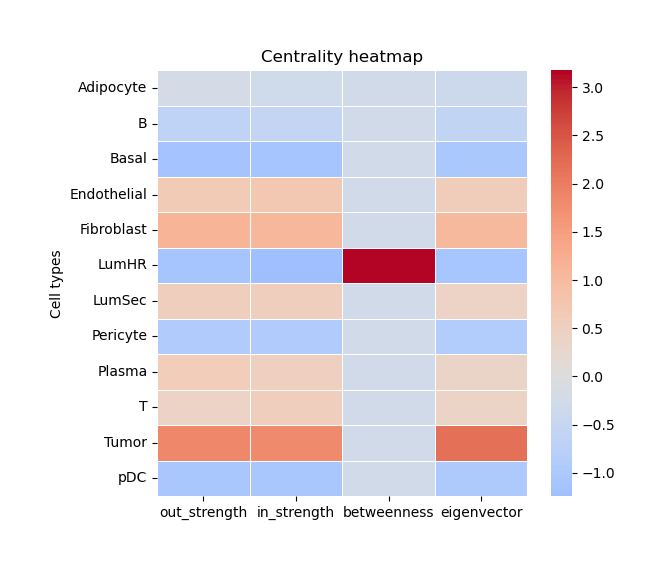

In [73]:
plot_centrality_heatmap(compute_centralities(network_sein))